### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Liwen(Wendy) Duan
*   Your **student number**: 1005892401



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [2]:
### YOUR CODE HERE ###
# 1. check structure of the original population dataset
print(raw_data.shape)
print(raw_data.columns.tolist())
raw_data.head()

(58824, 4)
['entity', 'code', 'year', 'population_historical']


,entity,code,year,population_historical
0,Afghanistan,AFG,-10000,14737
1,Afghanistan,AFG,-9000,20405
2,Afghanistan,AFG,-8000,28253
3,Afghanistan,AFG,-7000,39120
4,Afghanistan,AFG,-6000,54166


In [3]:
# 2. 237 countries list
countries_resp = requests.get(countries_list_url, headers=headers).text
valid_countries = [c.strip() for c in countries_resp.splitlines() if c.strip()]
print(f"{len(valid_countries)} countries ")
print(valid_countries[:10])

237 countries 
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia']


In [4]:
# 3. Keep only the 237 countries/regions in the list, and only years 1901-2023
df_filtered = raw_data[
    (raw_data['entity'].isin(valid_countries)) &
    (raw_data['year'] >= 1901) &
    (raw_data['year'] <= 2023)
]

# 4. Pivot into a table with country as rows, year as columns, values = population
df_pivot = df_filtered.pivot(index='entity', columns='year', values='population_historical')
print("shape / Pivot table shape:", df_pivot.shape)


# 5. Drop any country (row) that has a missing value in any year
df = df_pivot.dropna(axis=0, how='any')
print("shape / Shape after dropping missing values:", df.shape)
df.head()

shape / Pivot table shape: (237, 123)
shape / Shape after dropping missing values: (196, 123)


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [5]:
### YOUR CODE HERE ###

###1

import matplotlib.pyplot as plt

def plot_countries(df, country_list):
    """
    Takes a df (countries x years) and a list of countries,
    and plots each country's time series in a separate subplot
    """
    n = len(country_list)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n))
    if n == 1:
        axes = [axes]  # wrap in list if only one country
    for ax, country in zip(axes, country_list):
        ax.plot(df.columns, df.loc[country])
        ax.set_title(country)
        ax.set_xlabel('Year')
        ax.set_ylabel('Population')
    plt.tight_layout()
    plt.show()

In [6]:
###2
from sklearn.preprocessing import StandardScaler

# Standardize each year (each column) so mean=0 and std=1 across countries
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_values, index=df.index, columns=df.columns)

# Sanity check: mean should be ~0, std should be ~1 for each year
print(df_scaled.mean().iloc[:5])
print(df_scaled.std().iloc[:5])

year
1901   -3.398642e-18
1902   -1.132881e-17
1903   -3.016295e-17
1904    2.548981e-18
1905   -2.279922e-17
dtype: float64
year
1901    1.002561
1902    1.002561
1903    1.002561
1904    1.002561
1905    1.002561
dtype: float64


In [7]:
###3

!pip install python-Levenshtein -q
import Levenshtein

# Try both "Liwen" and "Wendy" to see which gives more sensible results
for first_name in ["Liwen", "Wendy"]:
    distances = {country: Levenshtein.distance(first_name, country) for country in df.index}
    sorted_countries = sorted(distances.items(), key=lambda x: x[1])
    print(f"\nClosest 10 countries using '{first_name}':")
    print(sorted_countries[:10])


Closest 10 countries using 'Liwen':
[('Libya', 3), ('Niger', 3), ('Taiwan', 3), ('Yemen', 3), ('Benin', 4), ('Chile', 4), ('Fiji', 4), ('Gabon', 4), ('Guinea', 4), ('Iran', 4)]

Closest 10 countries using 'Wendy':
[('Benin', 3), ('Kenya', 3), ('Canada', 4), ('Chad', 4), ('Congo', 4), ('Grenada', 4), ('India', 4), ('Italy', 4), ('Nepal', 4), ('Peru', 4)]


In [8]:
###4

# Countries chosen in Task 3
my_countries = ["Benin", "Kenya"]

# Add the 4 required countries from the assignment
target_countries = my_countries + ["Japan", "Bosnia and Herzegovina", "Latvia", "United Arab Emirates"]

# Check that all 6 countries survived the dropna step earlier, 41 countries have been deleted
missing = [c for c in target_countries if c not in df.index]
print("Countries NOT in df:", missing)

Countries NOT in df: []


Original data:


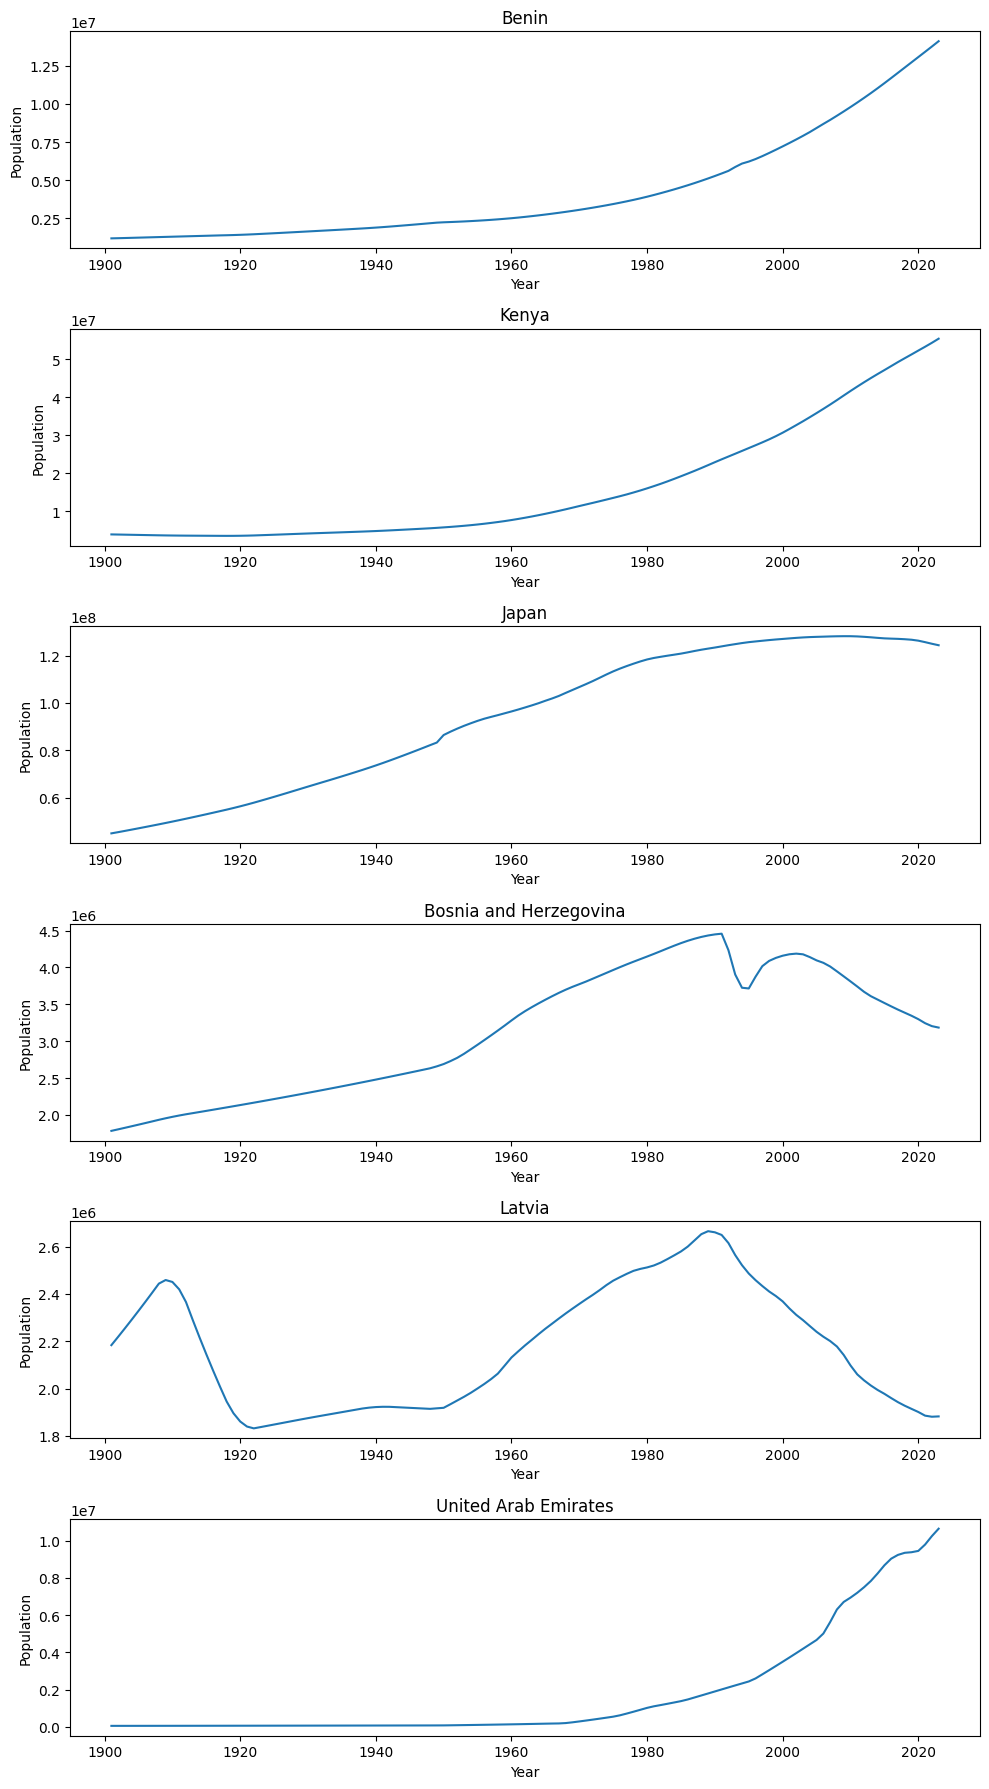

In [9]:
###4

print("Original data:")
plot_countries(df, target_countries)


Standardized data:


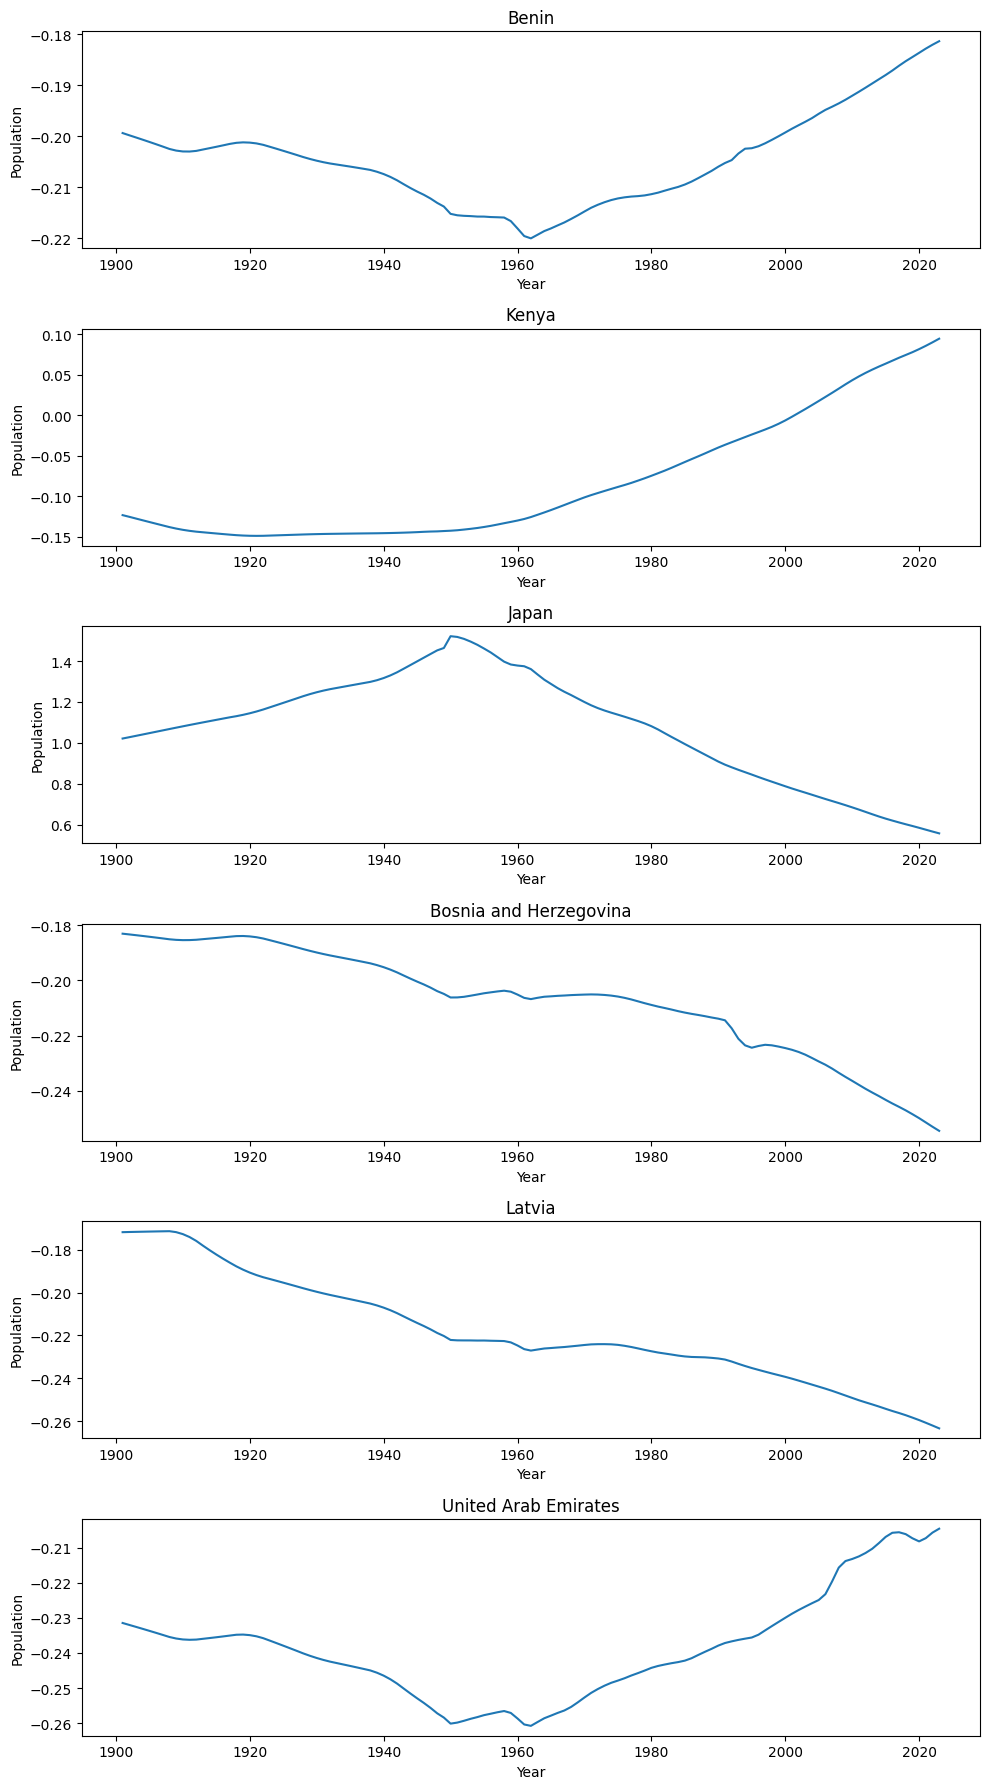

In [10]:
###4

print("Standardized data:")
plot_countries(df_scaled, target_countries)

5. Because each year was standardized across all 196 countries (mean 0, std 1), the value for a country in a given year shows how far its population is from that year's average across all countries, not from its own history. If the curve goes up, the country's population is growing faster than most other countries and moving closer to (or above) the average. If it goes down, the country is growing slower than average or losing population, so it falls further below the average. A positive value means the population is above that year's average; a negative value means it's below.

    Benin and Kenya both start below average and climb steadily — Kenya actually crosses into positive territory after 2000, showing its population grew faster than most countries, likely due to high birth rates. Japan stays positive the whole time (it's always been a large country) but peaks around 1950 and then slowly declines, matching its slowing growth and aging population in recent decades. Bosnia and Herzegovina and Latvia both stay negative and drift further down over time, with a sharp drop around the 1990s — for Bosnia this lines up with the 1992-1995 war, and for Latvia it's tied to emigration after the Soviet collapse. UAE is negative for most of the century but shoots up sharply after 1970 thanks to the oil boom and foreign labor, even though it's still below average overall.